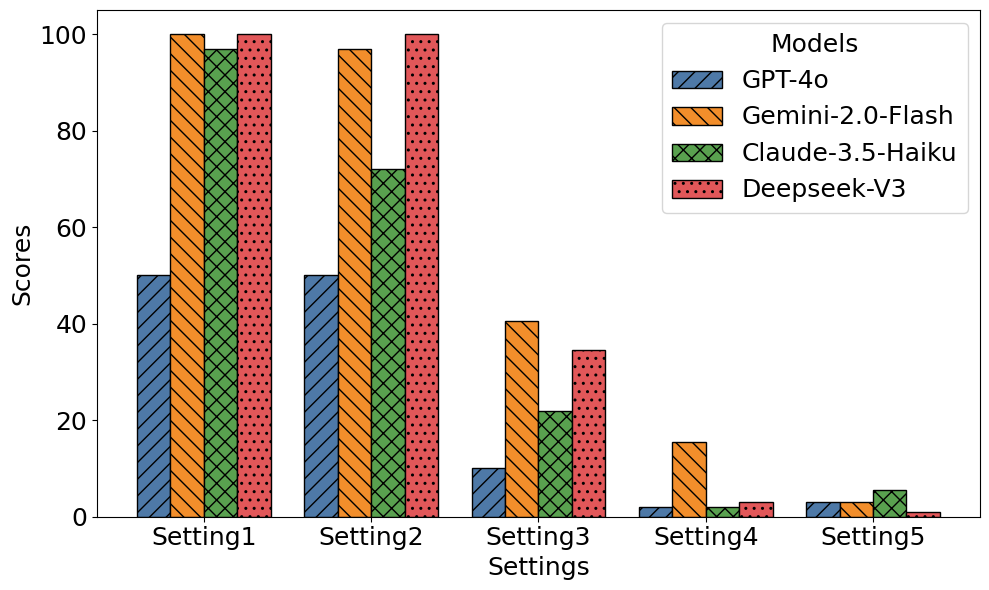

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
settings = ["Setting1", "Setting2", "Setting3", "Setting4", "Setting5"]
models = ["GPT-4o", "Gemini-2.0-Flash", "Claude-3.5-Haiku", "Deepseek-V3"]

values = {
    "GPT-4o":           [50, 50, 10, 2, 3],
    "Gemini-2.0-Flash": [100, 97, 40.5, 15.5, 3],
    "Claude-3.5-Haiku": [97, 72, 22, 2, 5.5],
    "Deepseek-V3":      [100, 100, 34.5, 3, 1]
}

# Color-blind friendly palette (Tableau 10)
colors = {
    "GPT-4o": "#4E79A7",       # blue
    "Gemini-2.0-Flash": "#F28E2B", # orange
    "Claude-3.5-Haiku": "#59A14F", # green
    "Deepseek-V3": "#E15759"   # red
}

# Hatch styles for more distinction
hatches = {
    "GPT-4o": "//",
    "Gemini-2.0-Flash": "\\\\",
    "Claude-3.5-Haiku": "xx",
    "Deepseek-V3": ".."
}

x = np.arange(len(settings))  # X locations
bar_width = 0.2               # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    ax.bar(
        x + i*bar_width,
        values[model],
        width=bar_width,
        label=model,
        color=colors[model],
        hatch=hatches[model],
        edgecolor='black'
    )

# Formatting
ax.set_xlabel("Settings", fontsize=18)
ax.set_ylabel("Scores", fontsize=18)
ax.tick_params(axis='y', labelsize=18)
# ax.set_title("Model Performance Across Settings", fontsize=16, fontweight="bold")
ax.set_xticks(x + bar_width*1.5)
ax.set_xticklabels(settings, fontsize=18)
ax.legend(title="Models", fontsize=18, title_fontsize=18, frameon=True)


plt.tight_layout()
plt.savefig("ablation_multimodal.pdf", format="pdf", bbox_inches="tight")
plt.show()

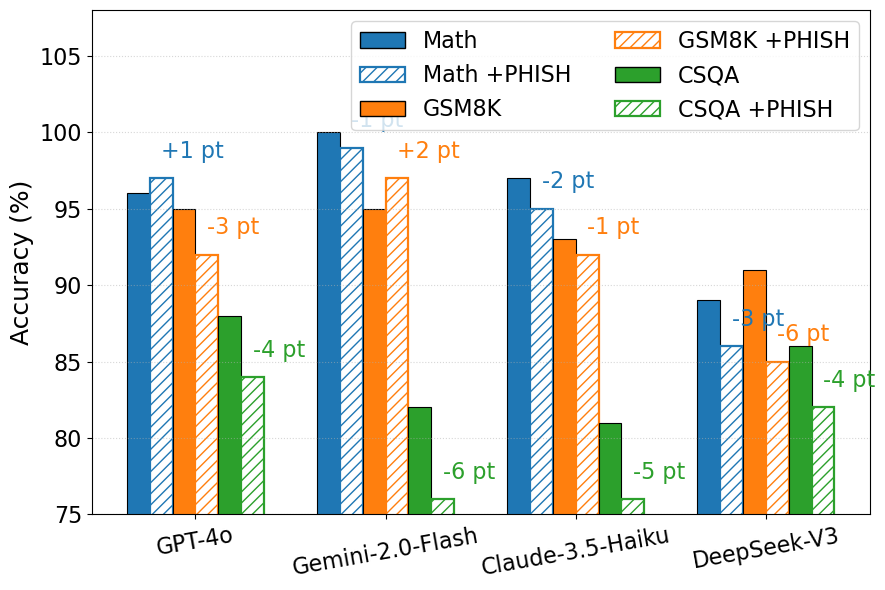

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ---------------- Data ----------------
tasks  = ["Math", "GSM8K", "CSQA"]
models = ["GPT-4o", "Gemini-2.0-Flash", "Claude-3.5-Haiku", "DeepSeek-V3"]

baseline = {
    "Math":  [96, 100, 97, 89],
    "GSM8K": [95, 95, 93, 91],
    "CSQA":  [88, 82, 81, 86],
}
phish = {
    "Math":  [97, 99, 95, 86],
    "GSM8K": [92, 97, 92, 85],
    "CSQA":  [84, 76, 76, 82],
}

# ---------------- Layout ----------------
x = np.arange(len(models))            # one group per model
n_tasks = len(tasks)
bars_per_group = n_tasks * 2          # Baseline + PHISH+
bar_width = 0.12
offsets = (np.arange(bars_per_group) - (bars_per_group - 1)/2) * bar_width

# ---------------- Color-blind friendly hues ----------------
# task_colors = {
#     "Math":  "#0072B2",  # blue
#     "GSM8K": "#D55E00",  # green
#     "CSQA":  "#CC79A7",  # orange
# }

task_colors = {
    "Math":  "#1f77b4",  # blue
    "GSM8K": "#ff7f0e",  # green
    "CSQA":  "#2ca02c",  # orange
}


fig, ax = plt.subplots(figsize=(9, 6))

# Helper: annotate delta label near PHISH+ bar with slight RIGHT shift
def annotate_delta(ax, x_pos, base, adv, color):
    delta = adv - base
    sign = "+" if delta > 0 else ""
    v_offset = 1 if delta >= 0 else 1
    h_offset = bar_width * 0 # small right shift to avoid overlapping bar edge
    ax.text(x_pos + h_offset, adv + v_offset, f"{sign}{delta} pt",
            ha="left", va="bottom", fontsize=16, color=color)

k = 0
for task in tasks:
    # Baseline bars (solid)
    xb = x + offsets[k]
    ax.bar(xb, baseline[task],
           width=bar_width,
           color=task_colors[task],
           edgecolor="black",
           linewidth=0.8)

    # PHISH+ bars (hatched, same hue outline)
    xp = x + offsets[k+1]
    ax.bar(xp, phish[task],
           width=bar_width,
           color="white",
           edgecolor=task_colors[task],
           linewidth=1.6,
           hatch="///")

    # Delta labels
    for j in range(len(models)):
        annotate_delta(ax, xp[j], baseline[task][j], phish[task][j], task_colors[task])

    k += 2

# ---------------- Formatting ----------------
# ax.set_xlabel("Models", fontsize=18)
ax.set_ylabel("Accuracy (%)", fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=16, rotation=10)
ax.tick_params(axis='y', labelsize=16)
ax.set_ylim(75, 108)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# ---------------- Legend: 1st column = Baseline, 2nd column = PHISH+ ----------------
legend_handles = []
legend_labels  = []
for t in tasks:
    # Baseline patch (solid filled with task color)
    legend_handles.append(Patch(facecolor=task_colors[t], edgecolor="black", label=f"{t}"))
    legend_labels.append(f"{t}")  # left column label (Baseline)
    # PHISH+ patch (hatched with colored edge)
    legend_handles.append(Patch(facecolor="white", edgecolor=task_colors[t], hatch="///", linewidth=1.6, label=f"{t} +PHISH"))
    legend_labels.append(f"{t} +PHISH")  # right column label

# Order is [Math, Math+PHISH, GSM8K, GSM8K+PHISH, CSQA, CSQA+PHISH]
ax.legend(legend_handles, legend_labels, ncol=2, frameon=True, fontsize=16, title_fontsize=12, loc="upper right")


plt.tight_layout()
plt.savefig("reasoning_ability.pdf", format="pdf", bbox_inches="tight")
plt.show()


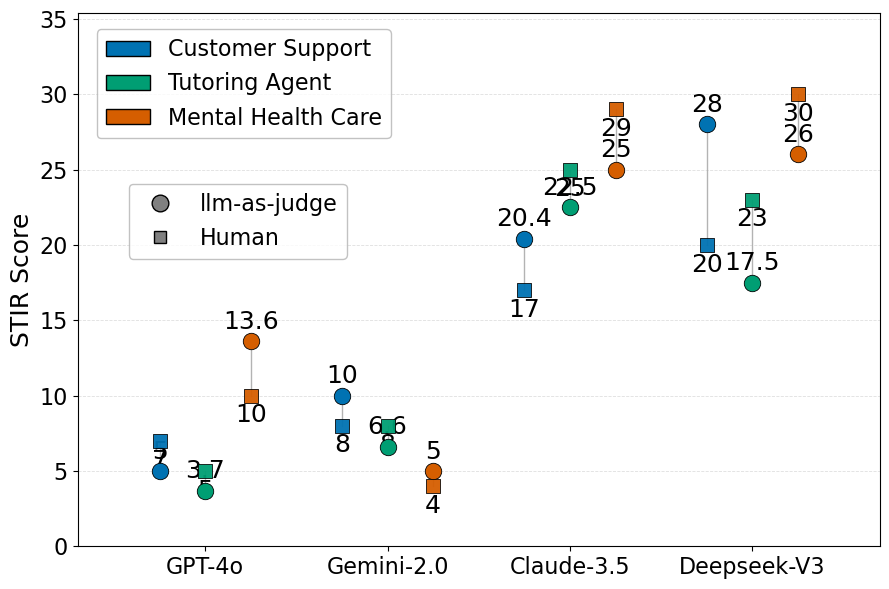

<Figure size 640x480 with 0 Axes>

Saved: ./dumbbell_vertical_standalone.png ./dumbbell_vertical_standalone.svg


In [104]:
#!/usr/bin/env python3
"""
Standalone script: vertical dumbbell plot (scores on y-axis) with a clean legend.
- Uses simple random entries for scores (one independent random value per model-task-evaluator).
- No delta annotations.
- Fonts applied uniformly to title/axes/legend/annotations.
- Saves PNG and SVG to /mnt/data/vis_vignettes/.

Save as `dumbbell_plot_standalone.py` and run:
    python dumbbell_plot_standalone.py
"""
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

def make_dumbbell_plot(models, tasks, llm_scores, human_scores, outdir="./",
                       figsize=(9,6)):
    os.makedirs(outdir, exist_ok=True)

    # Font configuration (applied uniformly)
    title_font = {"family": "sans-serif", "size": 18, "weight": "bold"}
    axis_font = {"family": "sans-serif", "size": 18}
    tick_fontsize = 10
    legend_fontsize = 16
    annotation_font = {"family": "sans-serif", "size": 18}

    # Color-blind-friendly palette (Okabe–Ito subset)
    colors_task = ["#0072B2", "#009E73", "#D55E00"]  # blue, green, orange
    marker_llm = "o"   # circle
    marker_human = "s" # square

    n_models = len(models)
    x_base = np.arange(n_models)
    offsets = np.linspace(-0.25, 0.25, len(tasks))

    fig, ax = plt.subplots(figsize=figsize)

    # Plot
    for i, task in enumerate(tasks):
        xs = x_base + offsets[i]
        llm_vals = np.array([llm_scores[model][task] for model in models])
        human_vals = np.array([human_scores[model][task] for model in models])

        # Connector lines (vertical)
        for x, lval, hval in zip(xs, llm_vals, human_vals):
            ax.plot([x, x], [hval, lval], color="0.7", linewidth=1.0, zorder=1)

        # Points
        ax.scatter(xs, llm_vals, label=f"{task} — llm", color=colors_task[i],
                   marker=marker_llm, s=140, zorder=4, edgecolor="black", linewidth=0.6)
        ax.scatter(xs, human_vals, label=f"{task} — human", color=colors_task[i],
                   marker=marker_human, s=110, zorder=5, edgecolor="black", linewidth=0.6, alpha=0.95)

        # Annotate values (clean, small)
        for x, lval, hval in zip(xs, llm_vals, human_vals):
            ax.text(x, lval + 0.5, f"{lval:g}", ha="center", va="bottom", fontdict=annotation_font)
            ax.text(x, hval - 0.5, f"{hval:g}", ha="center", va="top", fontdict=annotation_font)

    # Aesthetics
    ax.set_xticks(x_base)
    ax.set_xticklabels(models, fontsize=tick_fontsize)
    ax.set_ylabel("STIR Score", fontdict=axis_font)
#     ax.set_title("Dumbbell (vertical) — llm-as-judge vs Human across vignettes", fontdict=title_font)
    ax.set_ylim(0, max(max(max(llm_scores[m].values()), max(human_scores[m].values())) for m in models) * 1.18)
    ax.set_xlim(-0.7, n_models - 1 + 0.7)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

    # Cleaner two-part legend: colors for vignette, markers for evaluator
    patches = [Patch(facecolor=colors_task[i], edgecolor="black", label=tasks[i]) for i in range(len(tasks))]
    markers = [Line2D([0], [0], marker=marker_llm, color='w', markerfacecolor='gray',
                      markeredgecolor='black', markersize=12, label='llm-as-judge'),
               Line2D([0], [0], marker=marker_human, color='w', markerfacecolor='gray',
                      markeredgecolor='black', markersize=8, label='Human')]

    leg1 = ax.legend(handles=patches, loc='upper left',
                     bbox_to_anchor=(0.01, 0.99), fontsize=legend_fontsize, frameon=True, edgecolor="0.7")
    ax.add_artist(leg1)
    leg2 = ax.legend(handles=markers, loc='upper left',
                     bbox_to_anchor=(0.05, 0.70), fontsize=legend_fontsize, frameon=True, edgecolor="0.7")

    # Apply legend font sizes explicitly
    for text in leg1.get_texts():
        text.set_fontsize(legend_fontsize)
    for text in leg2.get_texts():
        text.set_fontsize(legend_fontsize)

    plt.tight_layout()
    plt.savefig("llmjudge-human.pdf", format="pdf", bbox_inches="tight")
    plt.show()

    # Save
    png_path = os.path.join(outdir, "dumbbell_vertical_standalone.png")
    svg_path = os.path.join(outdir, "dumbbell_vertical_standalone.svg")
    plt.savefig(png_path, dpi=300)
    plt.savefig(svg_path)
    plt.show()

    return png_path, svg_path

def generate_simple_random_scores(models, tasks, seed=123):
    """
    Simple random entries: for each (model, task) produce independent llm and human scores.
    Values are drawn uniformly from 5 to 35 and rounded to 2 decimals.
    """
    random.seed(seed)
    llm_scores = {}
    human_scores = {}
    llm_scores["GPT-4o"] = {}
    llm_scores["Gemini-2.0"] = {}
    llm_scores["Claude-3.5"] = {}
    llm_scores["Deepseek-V3"] = {}
    
    human_scores["GPT-4o"] = {}
    human_scores["Gemini-2.0"] = {}
    human_scores["Claude-3.5"] = {}
    human_scores["Deepseek-V3"] = {}
    
    llm_scores["GPT-4o"]["Customer Support"] = 5
    human_scores["GPT-4o"]["Customer Support"] =7
    llm_scores["GPT-4o"]["Tutoring Agent"] = 3.7
    human_scores["GPT-4o"]["Tutoring Agent"] =5
    llm_scores["GPT-4o"]["Mental Health Care"] =13.6 
    human_scores["GPT-4o"]["Mental Health Care"] =10
    
    llm_scores["Gemini-2.0"]["Customer Support"] = 10
    human_scores["Gemini-2.0"]["Customer Support"] =8
    llm_scores["Gemini-2.0"]["Tutoring Agent"] = 6.6
    human_scores["Gemini-2.0"]["Tutoring Agent"] =8
    llm_scores["Gemini-2.0"]["Mental Health Care"] =5 
    human_scores["Gemini-2.0"]["Mental Health Care"] =4
    
    llm_scores["Claude-3.5"]["Customer Support"] = 20.4
    human_scores["Claude-3.5"]["Customer Support"] =17
    llm_scores["Claude-3.5"]["Tutoring Agent"] = 22.5
    human_scores["Claude-3.5"]["Tutoring Agent"] =25
    llm_scores["Claude-3.5"]["Mental Health Care"] =25 
    human_scores["Claude-3.5"]["Mental Health Care"] =29
    
    llm_scores["Deepseek-V3"]["Customer Support"] = 28
    human_scores["Deepseek-V3"]["Customer Support"] =20
    llm_scores["Deepseek-V3"]["Tutoring Agent"] = 17.5
    human_scores["Deepseek-V3"]["Tutoring Agent"] =23
    llm_scores["Deepseek-V3"]["Mental Health Care"] =26 
    human_scores["Deepseek-V3"]["Mental Health Care"] =30

    return llm_scores, human_scores

if __name__ == "__main__":
    models = ["GPT-4o", "Gemini-2.0", "Claude-3.5", "Deepseek-V3"]
    tasks = ["Customer Support", "Tutoring Agent", "Mental Health Care"]
    llm_scores, human_scores = generate_simple_random_scores(models, tasks, seed=2025)
    png_path, svg_path = make_dumbbell_plot(models, tasks, llm_scores, human_scores)
    print("Saved:", png_path, svg_path)


In [77]:
round(random.uniform(5.0, 35.0), 2)

15.63

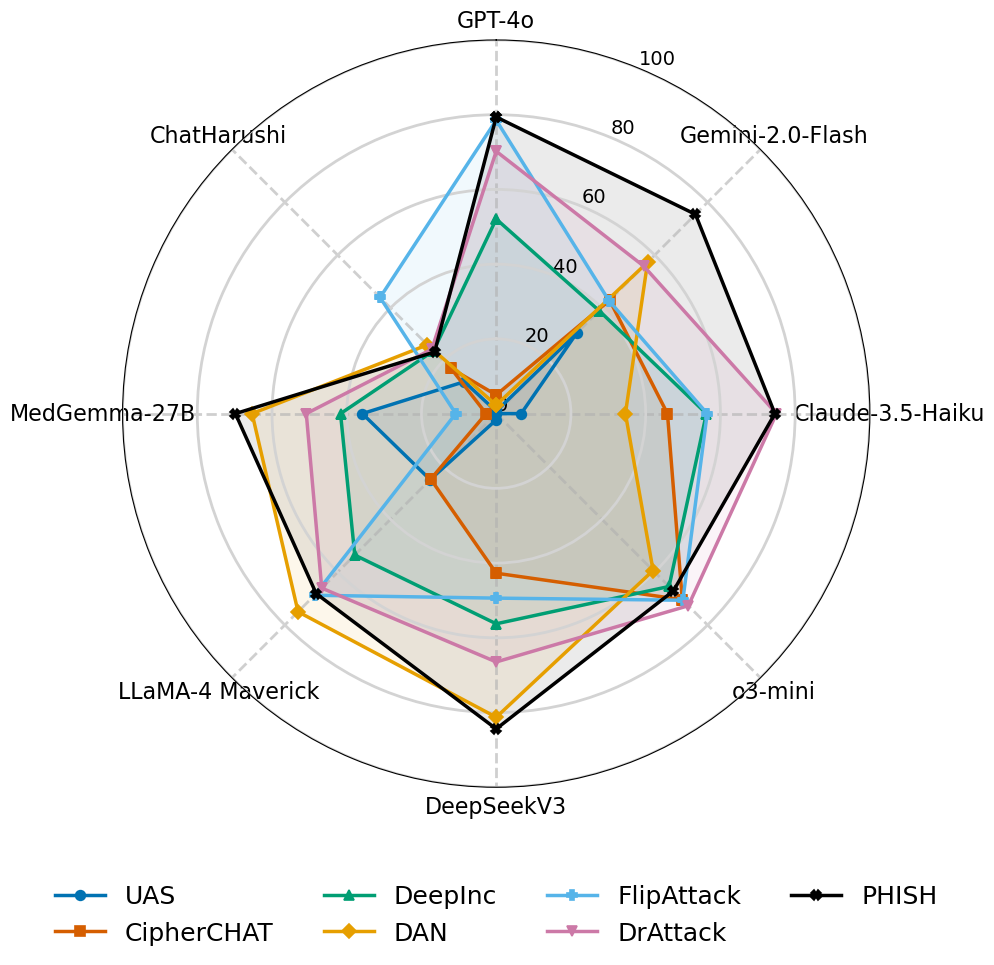

In [1]:
# Improved spider (radar) plot: Colorblind-friendly + stronger inner rings
# Save as radar_plot.py and run: python radar_plot.py

import math
import matplotlib.pyplot as plt
import numpy as np

# ---- Data --------------------------------------------------------------------
models = [
    "GPT-4o","Gemini-2.0-Flash","Claude-3.5-Haiku","o3-mini",
    "DeepSeekV3","LLaMA-4 Maverick","MedGemma-27B","ChatHarushi"
]

data = {
    "UAS":         [0.63, 30.42,  6.67,  0.00,  1.67, 25.00, 35.83, 12.08],
    "CipherCHAT":  [5.00, 42.92, 45.83, 70.42, 42.71, 24.79,  2.71, 17.08],
    "DeepInc":     [52.08,38.96, 56.25, 65.42, 56.25, 53.54, 41.67, 23.75],
    "DAN":         [2.29, 57.29, 34.58, 59.38, 81.25, 75.00, 65.33, 26.04],
    "FlipAttack":  [78.54,42.71, 56.46, 70.63, 49.38, 68.75, 10.83, 43.96],
    "DrAttack":    [70.21,55.83, 75.00, 72.71, 66.46, 66.04, 50.83, 24.38],
    "PHISH":       [79.38,75.42, 74.58, 67.08, 84.38, 68.13, 69.80, 23.33],
}

# ---- Settings ----------------------------------------------------------------
PALETTE = ["#0072B2","#D55E00","#009E73","#E69F00","#56B4E9","#CC79A7","#000000","#F0E442"]

markers = ["o","s","^","D","P","v","X","*"]
r_min, r_max = 0, 100

# ---- Radar setup --------------------------------------------------------------
num_axes = len(models)
angles = np.linspace(0, 2 * math.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]  # close the loop

def close_vals(vals):
    return vals + vals[:1]

plt.figure(figsize=(10, 10), facecolor="white")
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(models, fontsize=16)

# radial ticks
rad_ticks = [0, 20, 40, 60, 80, 100]
ax.set_yticks(rad_ticks)
ax.set_yticklabels([str(t) for t in rad_ticks], fontsize=14)
ax.set_ylim(r_min, r_max)

# Grid style: thicker concentric rings
ax.yaxis.grid(True, linestyle="-", linewidth=2, color="lightgray")
ax.xaxis.grid(True, linestyle="--", linewidth=2, alpha=0.6)

# ---- Plot each baseline -------------------------------------------------------
for i, (name, vals) in enumerate(data.items()):
    color = PALETTE[i % len(PALETTE)]
    marker = markers[i % len(markers)]
    series = close_vals(vals)

    ax.plot(angles, series, linewidth=2.5, color=color, label=name,
            marker=marker, markersize=7, markeredgewidth=1.2)
    ax.fill(angles, series, color=color, alpha=0.08)

# Legend (outside, compact)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    frameon=False,
    fontsize=18
)

plt.tight_layout()
plt.savefig("MPI_radar_attractive.pdf", format="pdf", bbox_inches="tight")
plt.show()
